# Exercise 07: Imputation of Missing Values

**CBIOMES Workshop · Time Series in R**

In this notebook you will:

1. Inject realistic missingness into a known AR(1) process.
2. Impute the gaps with **four** different methods (linear, spline, Random Forest, Kalman).
3. Compare them on **two** criteria: point-wise RMSE *and* preservation of the AR(1) parameter $\phi$.
4. Apply imputation to a real dataset with naturally occurring gaps.

## Setup

All packages already installed in the Docker container.

Expected files: `time_series.csv` and `metadata.csv` (real datasets with missing values).

In [1]:
#library(tidyverse)
library(zoo)         # na.approx, na.spline
#library(imputeTS)    # na_kalman
library(missForest)  # missForest
library(tidyr)
library(ggplot2)


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




## Background: why "filling the gaps" is harder than it sounds

| Method | What it does | Strengths | Weaknesses |
|---|---|---|---|
| **Linear** | straight line between neighbours | simple, fast | kills volatility |
| **Spline** | smooth curve through neighbours | natural-looking | can over-shoot |
| **Random Forest** (`missForest`) | predicts missing values from other variables and lags | uses external info | needs enough data, can be slow |

A method can be **great at point reconstruction** (low RMSE) and **terrible at preserving dynamics** (biased $\hat\phi$). We'll see this happen.

---

## Exercise 1: Controlled experiment with a known AR(1)

### Part 1: Simulate a stationary AR(1) with $\phi = 0.7$

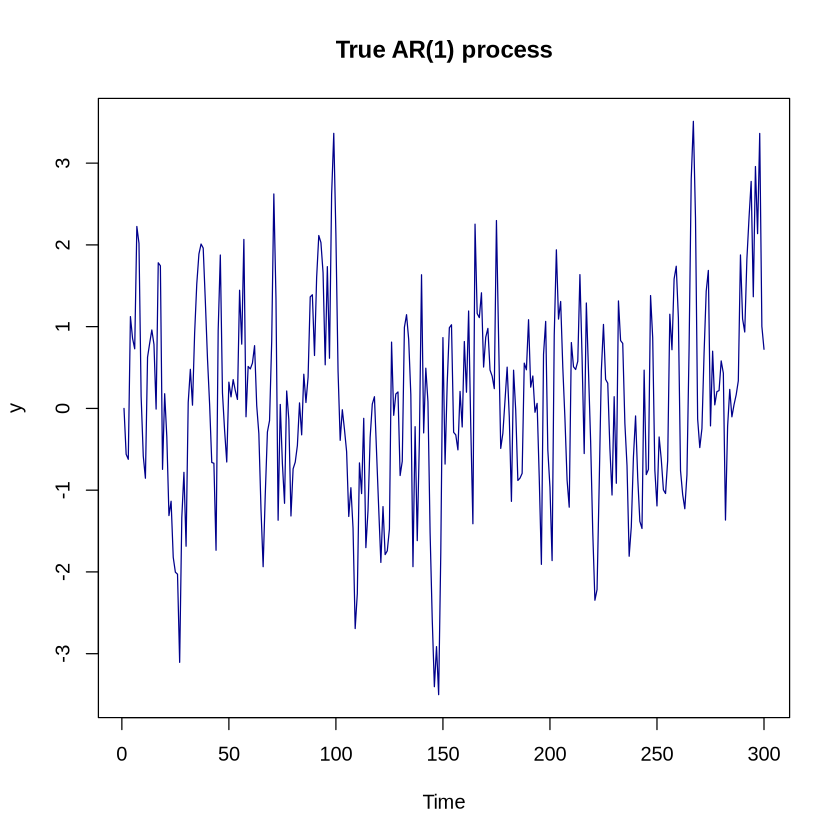

In [2]:
set.seed(123)
T    <- 300
phi1 <- 0.7

y_true <- numeric(T)
for (t in 2:T) {
    y_true[t] <- phi1 * y_true[t - 1] + rnorm(1)
}

plot(y_true, type = "l", col = "darkblue",
     main = "True AR(1) process", xlab = "Time", ylab = "y")

### Part 2: Introduce missing values

We'll create 10 gaps of random length (1–3 consecutive observations) at random positions.

Number of missing values: 18 


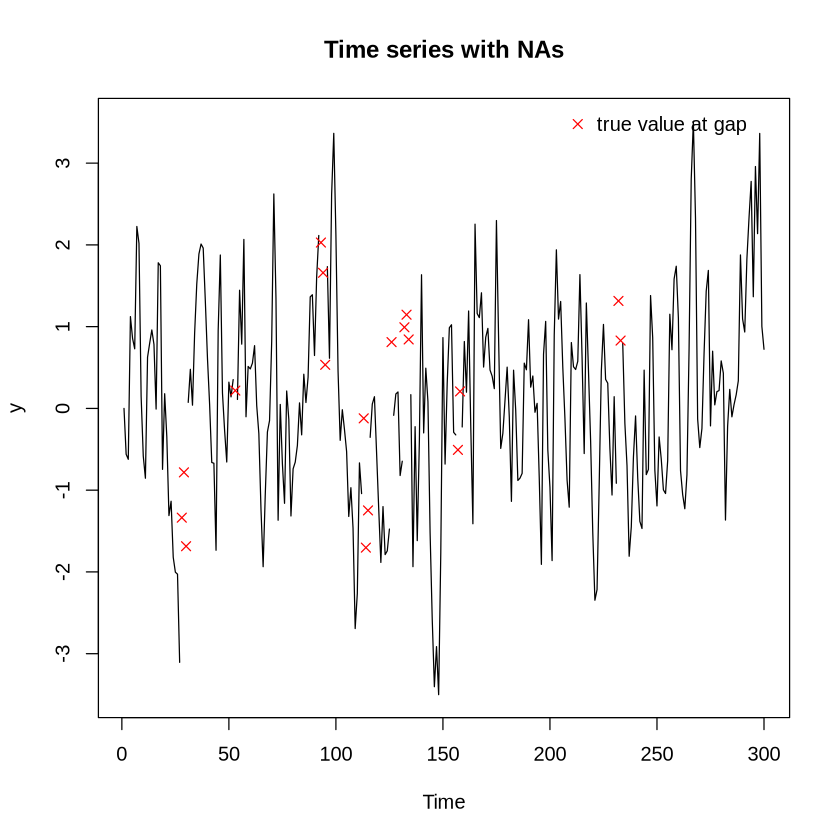

In [3]:
y_miss <- y_true
n_holes <- 10

set.seed(42)
for (i in 1:n_holes) {
    start <- sample(5:(T - 5), 1)
    len   <- sample(1:3, 1)
    y_miss[start:(start + len - 1)] <- NA
}
miss_idx <- which(is.na(y_miss))

cat("Number of missing values:", length(miss_idx), "\n")

plot(y_miss, type = "l",
     main = "Time series with NAs",
     xlab = "Time", ylab = "y")
points(miss_idx, y_true[miss_idx], col = "red", pch = 4)
legend("topright", legend = "true value at gap",
       col = "red", pch = 4, bty = "n")

### Part 3: Apply four imputation methods

### Hints

- `na.approx(x, na.rm = FALSE)` and `na.spline(x, na.rm = FALSE)` come from `zoo`.
- `na_kalman(x, model = "auto.arima")` from `imputeTS` fits an ARIMA underneath and uses the Kalman filter.
- For Random Forest, build a small data frame with the variable plus a couple of lag columns.

In [4]:
# 1) Linear interpolation
y_linear <- na.approx(y_miss, na.rm = FALSE)

# 2) Spline interpolation
y_spline <- na.spline(y_miss, na.rm = FALSE)

# 3) Random Forest with two lags as features
df_rf <- data.frame(
    y    = y_miss,
    t    = 1:T,
    lag1 = c(NA, y_miss[-T]),
    lag2 = c(NA, NA, y_miss[-((T-1):T)])
)
rf_res <- missForest(df_rf)
y_rf   <- y_miss
y_rf[miss_idx] <- rf_res$ximp$y[miss_idx]

# 4) Kalman with ARIMA model
#y_kalman <- na_kalman(y_miss, model = "auto.arima")

### Part 4: RMSE at the missing locations only

In [5]:
rmse_at_gaps <- function(pred, true, idx) {
    sqrt(mean((pred[idx] - true[idx])^2))
}

cat("RMSE at gap locations:\n")
cat(sprintf("  Linear : %.3f\n", rmse_at_gaps(y_linear, y_true, miss_idx)))
cat(sprintf("  Spline : %.3f\n", rmse_at_gaps(y_spline, y_true, miss_idx)))
cat(sprintf("  RF     : %.3f\n", rmse_at_gaps(y_rf,     y_true, miss_idx)))
#cat(sprintf("  Kalman : %.3f\n", rmse_at_gaps(y_kalman, y_true, miss_idx)))

RMSE at gap locations:
  Linear : 0.970
  Spline : 1.183
  RF     : 1.192


### Part 5: Effect on the estimated $\phi$

Now estimate $\phi$ from each imputed series and compare to the true value 0.7.

In [6]:
estimate_ar1 <- function(y) {
    fit <- arima(y, order = c(1, 0, 0), method = "ML")
    as.numeric(fit$coef["ar1"])
}

phi_est <- c(
    True   = estimate_ar1(y_true),
    Linear = estimate_ar1(y_linear),
    Spline = estimate_ar1(y_spline),
    RF     = estimate_ar1(y_rf)
#    Kalman = estimate_ar1(y_kalman)
)
print(round(phi_est, 4))

  True Linear Spline     RF 
0.6377 0.6654 0.6773 0.6507 


### Part 6: Visual comparison in a window

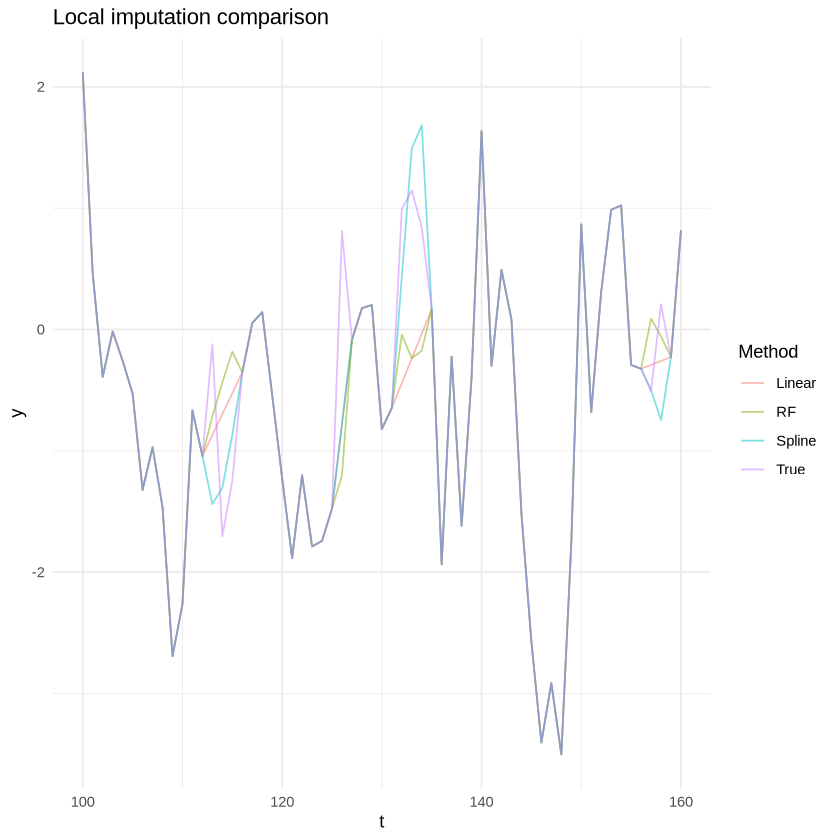

In [7]:
win <- 100:160

df_plot <- data.frame(
    t      = win,
    True   = y_true[win],
    Linear = y_linear[win],
    Spline = y_spline[win],
    RF     = y_rf[win]) %>%
    pivot_longer(-t, names_to = "Method", values_to = "y")

ggplot(df_plot, aes(x = t, y = y, color = Method)) +
    geom_line(alpha = 0.5) +
    theme_minimal() +
    labs(title = "Local imputation comparison")

### Part 7: RMSE vs. parameter error

Are the two metrics aligned? Often *no*.

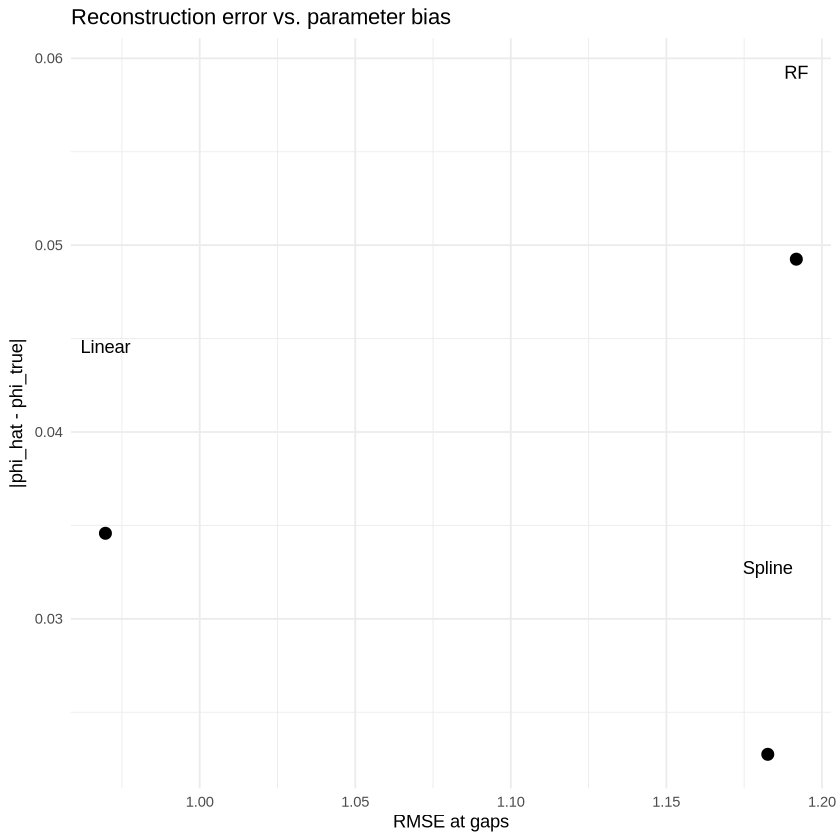

In [8]:
phi_true <- phi1
df_compare <- data.frame(
    Method = names(phi_est)[-1],
    RMSE = c(
        rmse_at_gaps(y_linear, y_true, miss_idx),
        rmse_at_gaps(y_spline, y_true, miss_idx),
        rmse_at_gaps(y_rf,     y_true, miss_idx)),
    PhiError = abs(phi_est[-1] - phi_true)
)

ggplot(df_compare, aes(x = RMSE, y = PhiError, label = Method)) +
    geom_point(size = 3) +
    geom_text(nudge_y = 0.01) +
    theme_minimal() +
    labs(title = "Reconstruction error vs. parameter bias",
         x = "RMSE at gaps",
         y = "|phi_hat - phi_true|")

Linear interpolation often wins on RMSE because it draws a straight line right between the neighbours, but that flattens out variability and **biases $\hat\phi$**. 

### Discussion

- When does point-RMSE matter more than parameter preservation, and vice versa?
- Why does spline sometimes overshoot in volatile regions?
- What feature engineering would make Random Forest work better here?

---

## Exercise 2: Real data with naturally occurring gap

In [9]:
time_series <- as.data.frame(read.csv("time_series.csv"))
cat("Dimensions:", dim(time_series), "\n")
cat("Total NAs:", sum(is.na(time_series)), "\n")

df <- data.frame(
    time  = seq_len(nrow(time_series)),
    value = time_series[, 3]
)
head(df)
summary(df)

Dimensions: 144 50 
Total NAs: 150 


,time,value
,<int>,<dbl>
1,1,8.861137
2,2,9.087965
3,3,8.808485
4,4,8.555214
5,5,8.550335
6,6,9.069090


      time            value       
 Min.   :  1.00   Min.   : 6.045  
 1st Qu.: 36.75   1st Qu.: 7.860  
 Median : 72.50   Median : 8.676  
 Mean   : 72.50   Mean   : 8.590  
 3rd Qu.:108.25   3rd Qu.: 9.399  
 Max.   :144.00   Max.   :10.476  
                  NA's   :3       

### Visualising the gaps

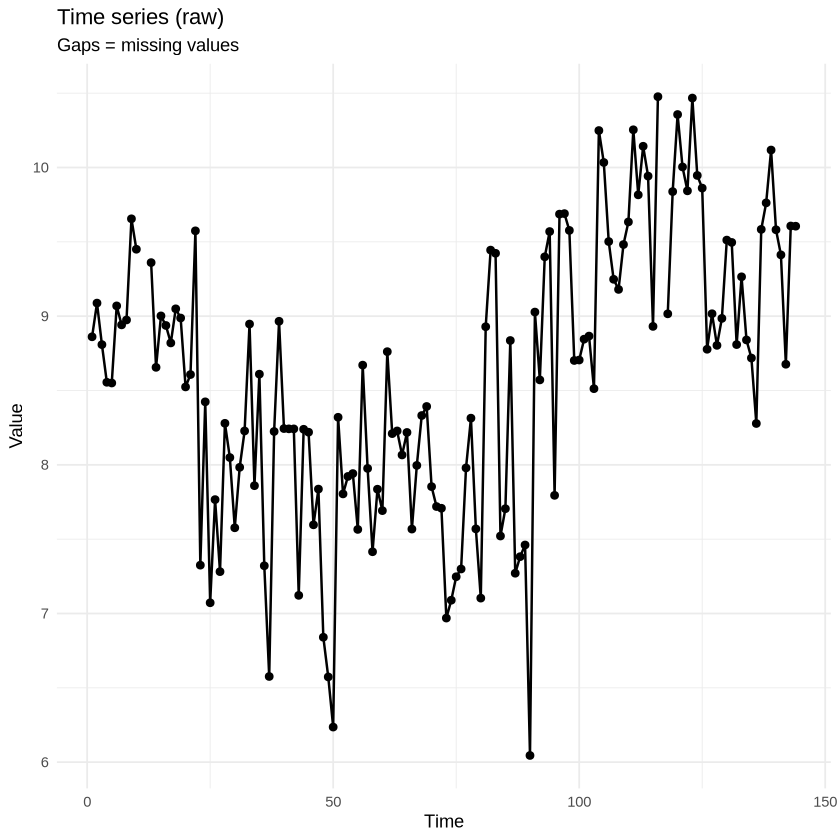

In [10]:
ggplot(df, aes(x = time, y = value)) +
    geom_line(linewidth = 0.7) +
    geom_point(data = subset(df, !is.na(value)), size = 1.8) +
    labs(title = "Time series (raw)",
         subtitle = "Gaps = missing values",
         x = "Time", y = "Value") +
    theme_minimal()

### Imputing with `missForest`

`missForest` uses the relationships **between** variables to fill in missing values — that's why we pass the entire data frame, not just one column.

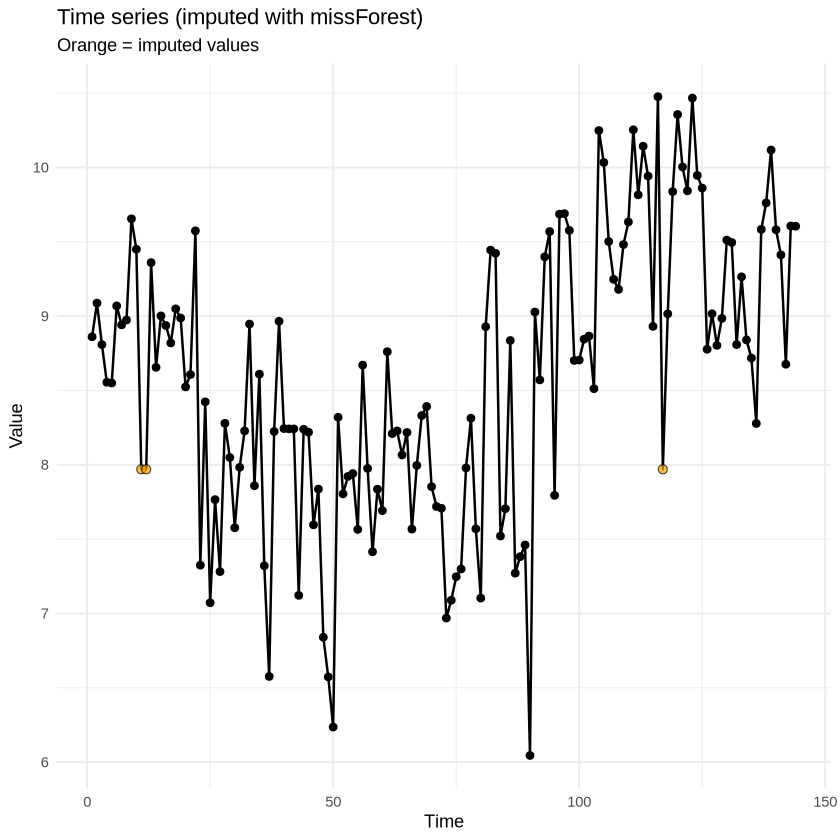

In [11]:
set.seed(123)
time_series_imp <- missForest(time_series)$ximp

df_imp <- data.frame(
    time    = seq_len(nrow(time_series_imp)),
    value   = time_series_imp[, 3],
    imputed = is.na(time_series[, 3])
)

ggplot(df_imp, aes(x = time, y = value)) +
    geom_line(linewidth = 0.7) +
    geom_point(data = subset(df_imp, !imputed), size = 1.8) +
    geom_point(data = subset(df_imp, imputed),
               size = 2.2, shape = 21, fill = "orange", alpha = 0.7) +
    labs(title = "Time series (imputed with missForest)",
         subtitle = "Orange = imputed values",
         x = "Time", y = "Value") +
    theme_minimal()

### Same workflow on `metadata.csv`

Warning message:
“Removed 30 rows containing missing values or values outside the scale range
(`geom_line()`).”


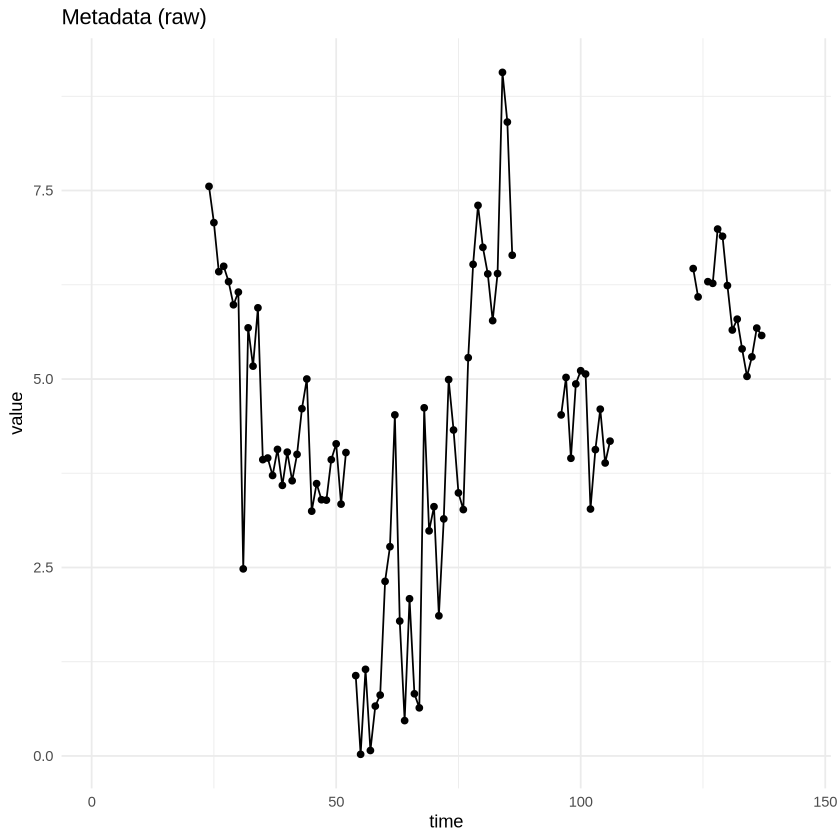

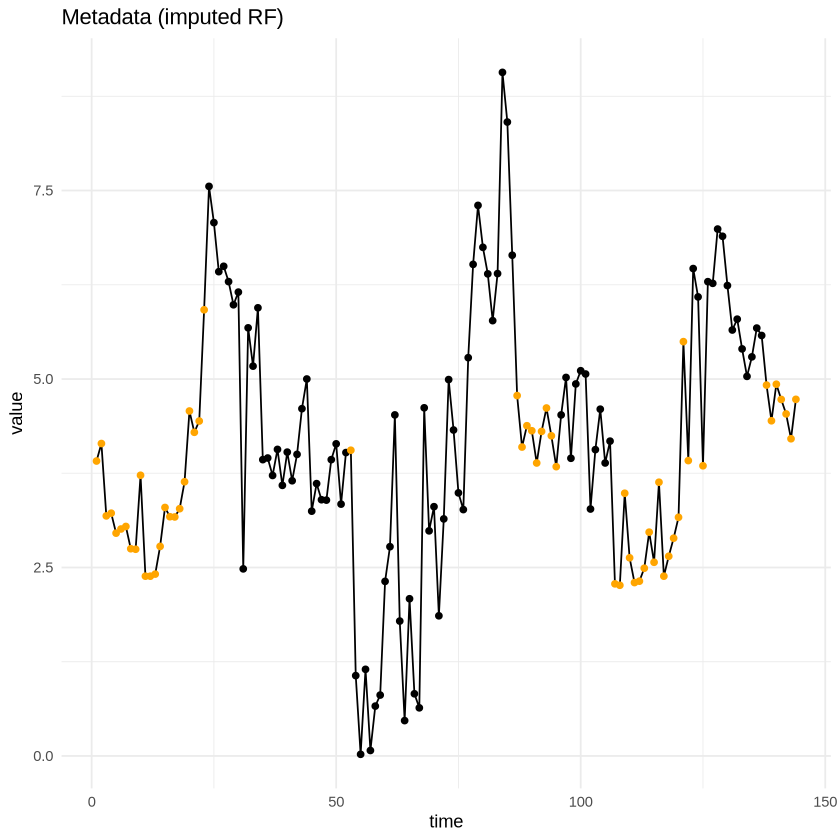

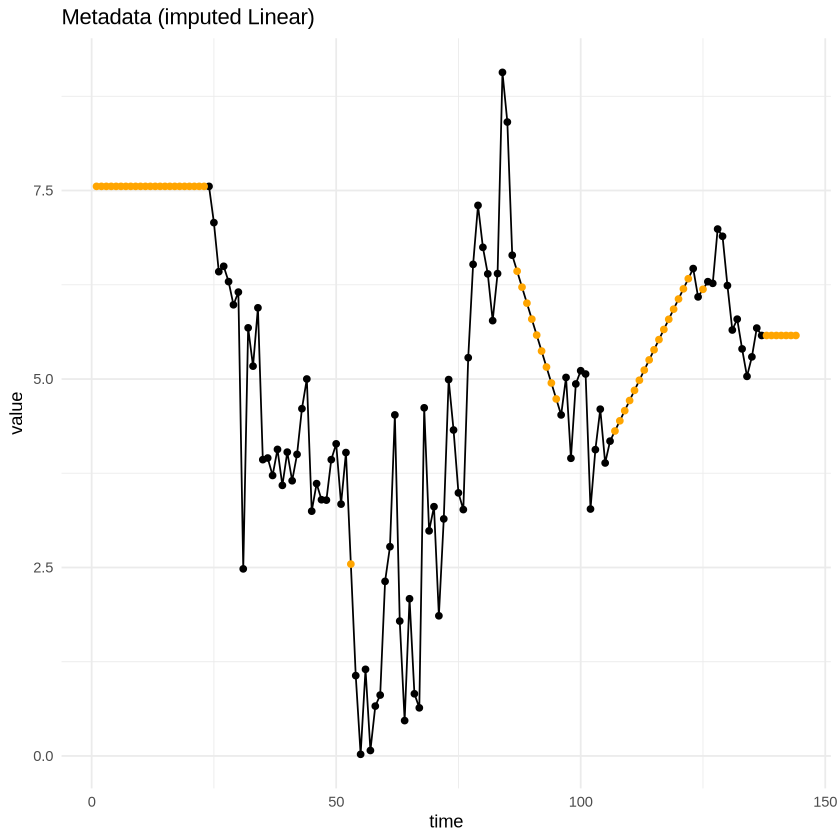

In [12]:
metadata_time_series <- as.data.frame(read.csv("metadata.csv"))

# Linear interpolation on column 2
y_miss_meta <- metadata_time_series[, 2]
y_lin <- na.approx(y_miss_meta, na.rm = FALSE, rule = 2)

df_meta_lin <- data.frame(
    time    = seq_along(y_lin),
    value   = y_lin,
    imputed = is.na(y_miss_meta)
)

# missForest on the whole thing
metadata_time_series_imp <- missForest(metadata_time_series)$ximp
df_meta_imp <- data.frame(
    time    = seq_len(nrow(metadata_time_series_imp)),
    value   = metadata_time_series_imp[, 2],
    imputed = is.na(metadata_time_series[, 2])
)

# Side-by-side plots
df_meta <- data.frame(time = seq_along(y_miss_meta), value = y_miss_meta)
p1 <- ggplot(df_meta, aes(x = time, y = value)) +
    geom_line() +
    geom_point(data = subset(df_meta, !is.na(value))) +
    theme_minimal() + labs(title = "Metadata (raw)")

p2 <- ggplot(df_meta_imp, aes(x = time, y = value)) +
    geom_line() +
    geom_point(data = subset(df_meta_imp, !imputed)) +
    geom_point(data = subset(df_meta_imp, imputed), color = "orange") +
    theme_minimal() + labs(title = "Metadata (imputed RF)")

p3 <- ggplot(df_meta_lin, aes(x = time, y = value)) +
    geom_line() +
    geom_point(data = subset(df_meta_lin, !imputed)) +
    geom_point(data = subset(df_meta_lin, imputed), color = "orange") +
    theme_minimal() + labs(title = "Metadata (imputed Linear)")

p1; p2; p3

### Common pitfalls

- Imputing column-by-column when the variables are correlated → throws away the cross-information that makes RF and similar methods shine.
- Using point-RMSE as the **only** evaluation metric.
- Re-imputing iteratively → can drift if not careful.

---

## Wrap-up

- Inject controlled missingness, impute, and compare four methods.
- Distinguish **point-reconstruction quality** from **dynamics preservation**.
- Apply `missForest` to a real multivariate dataset with naturally occurring gaps.

Next: **endogenous vs exogenous** variables (Exercise 08).